# MedMNIST v2 Resampling Perturbation Benchmark (All 2D Datasets)

This notebook benchmarks up/down-sampling perturbations on all 12 MedMNIST v2 2D datasets using the team pretrained ResNet18 weights (no retraining).

Key design points:
- Perturbation is applied before tensor conversion and ImageNet normalization.
- Grid: 4 scale factors x 5 interpolation methods = 20 perturbation settings.
- Clean baseline is computed per dataset and used for accuracy-drop and flip-rate comparisons.
- Cache-aware execution reuses local data, weights, and saved metrics.

In [ ]:
%pip install -q medmnist scikit-learn matplotlib seaborn Pillow torchvision pandas tqdm opencv-python-headless scikit-image

import json
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torchvision.models as tv_models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.metrics import accuracy_score
from skimage.metrics import structural_similarity as ssim
from torch.nn.functional import softmax
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import medmnist
from medmnist import INFO

import matplotlib.pyplot as plt
import seaborn as sns

# Repro + environment
torch.manual_seed(42)
np.random.seed(42)

FORCE_CPU = True
device = torch.device('cpu' if FORCE_CPU or not torch.cuda.is_available() else 'cuda')
print(f'Using device: {device}')

CACHE_ROOT = Path('./medmnist_cache')
DATA_ROOT = CACHE_ROOT / 'data'
WEIGHTS_ROOT = CACHE_ROOT / 'weights'
RESULTS_ROOT = CACHE_ROOT / 'results'
PER_IMAGE_ROOT = RESULTS_ROOT / 'per_image'
for p in [CACHE_ROOT, DATA_ROOT, WEIGHTS_ROOT, RESULTS_ROOT, PER_IMAGE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

PERTURB_CONFIG = {
    'scale_factors': [2, 4, 8, 16],
    'interpolation_methods': ['nearest', 'bilinear', 'bicubic', 'lanczos', 'area']
}

INTERP_MAP = {
    'nearest': cv2.INTER_NEAREST,
    'bilinear': cv2.INTER_LINEAR,
    'bicubic': cv2.INTER_CUBIC,
    'lanczos': cv2.INTER_LANCZOS4,
    'area': cv2.INTER_AREA
}

RESULTS_CSV = RESULTS_ROOT / 'resampling_perturbation_metrics.csv'
RESULTS_JSON = RESULTS_ROOT / 'resampling_perturbation_metrics.json'
STATUS_CSV = RESULTS_ROOT / 'resampling_perturbation_status.csv'

FORCE_RERUN = False
SAVE_PER_IMAGE_PREDICTIONS = False

Using device: cpu


## Dataset Discovery (2D vs 3D)

This experiment evaluates all MedMNIST 2D datasets and reports 3D datasets as not evaluated in this notebook, because 3D variants require volumetric models and 3D interpolation.

In [ ]:
all_flags = sorted(INFO.keys())
flags_2d = [f for f in all_flags if '3d' not in f.lower()]
flags_3d = [f for f in all_flags if '3d' in f.lower()]

print(f'Total MedMNIST datasets in INFO: {len(all_flags)}')
print(f'2D datasets (evaluated): {len(flags_2d)}')
print(f'3D datasets (tracked only): {len(flags_3d)}')

if len(flags_2d) != 12:
    print('Warning: expected 12 2D datasets in MedMNIST v2, found:', len(flags_2d))

print('\n2D flags:', flags_2d)
print('\n3D flags:', flags_3d)

print('\nPerturbation grid size:', len(PERTURB_CONFIG['scale_factors']) * len(PERTURB_CONFIG['interpolation_methods']))

Total MedMNIST datasets in INFO: 18
2D datasets (evaluated here): 12
3D datasets (tracked, not evaluated here): 6

2D: ['bloodmnist', 'breastmnist', 'chestmnist', 'dermamnist', 'octmnist', 'organamnist', 'organcmnist', 'organsmnist', 'pathmnist', 'pneumoniamnist', 'retinamnist', 'tissuemnist']

3D: ['adrenalmnist3d', 'fracturemnist3d', 'nodulemnist3d', 'organmnist3d', 'synapsemnist3d', 'vesselmnist3d']


## Helpers: Caching, Resampling Perturbation, Inference, and Metrics

This section defines the OpenCV perturbation function and the dataset/model utilities used for the full benchmark.

In [ ]:
def download_if_missing(url: str, dest: Path):
    if dest.exists():
        return
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, str(dest))


def ensure_dataset_224_npz(data_flag: str, size: int = 224) -> Path:
    npz_file = DATA_ROOT / f'{data_flag}_{size}.npz'
    url = f'https://zenodo.org/records/10519652/files/{data_flag}_{size}.npz?download=1'
    download_if_missing(url, npz_file)
    return npz_file


def ensure_resnet18_weights(data_flag: str) -> Path:
    weights_file = WEIGHTS_ROOT / f'{data_flag}_resnet18_224.pth'
    if weights_file.exists():
        return weights_file

    zip_path = WEIGHTS_ROOT / f'weights_{data_flag}.zip'
    zip_url = f'https://zenodo.org/records/7782114/files/weights_{data_flag}.zip?download=1'
    download_if_missing(zip_url, zip_path)

    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = zf.namelist()
        preferred = 'resnet18_224_1.pth'
        chosen = preferred if preferred in names else next((n for n in names if n.endswith('.pth')), None)
        if chosen is None:
            raise RuntimeError(f'No .pth file found inside {zip_path.name}')
        with zf.open(chosen) as src, open(weights_file, 'wb') as dst:
            dst.write(src.read())

    return weights_file


def load_model(weights_path: Path, n_classes: int):
    model = tv_models.resnet18(weights=None, num_classes=n_classes).to(device)
    ckpt = torch.load(str(weights_path), map_location=device)
    state_dict = ckpt['net'] if isinstance(ckpt, dict) and 'net' in ckpt else ckpt
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


def pil_to_uint8_rgb_np(image):
    if isinstance(image, Image.Image):
        img = image
    else:
        img = Image.fromarray(image)

    if img.mode != 'RGB':
        img = img.convert('RGB')

    return np.array(img, dtype=np.uint8)


def apply_resampling(image, scale_factor, interpolation_method):
    """
    Apply 224->target->224 resampling perturbation using OpenCV.
    Accepts PIL image or numpy array and returns PIL.Image (RGB, 224x224).
    """
    if interpolation_method not in INTERP_MAP:
        raise ValueError(f'Unknown interpolation method: {interpolation_method}')

    arr = pil_to_uint8_rgb_np(image)
    h, w = arr.shape[:2]
    if h != SIZE or w != SIZE:
        arr = cv2.resize(arr, (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)

    target = SIZE // scale_factor
    interp = INTERP_MAP[interpolation_method]

    down = cv2.resize(arr, (target, target), interpolation=interp)
    up = cv2.resize(down, (SIZE, SIZE), interpolation=interp)

    return Image.fromarray(up)


def make_base_preprocess():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])


class PerturbedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, scale_factor=None, interpolation_method=None):
        self.base_dataset = base_dataset
        self.scale_factor = scale_factor
        self.interpolation_method = interpolation_method
        self.preprocess = make_base_preprocess()

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        clean_rgb = pil_to_uint8_rgb_np(img)

        if self.scale_factor is None or self.interpolation_method is None:
            pert_rgb = clean_rgb
        else:
            pert_pil = apply_resampling(clean_rgb, self.scale_factor, self.interpolation_method)
            pert_rgb = np.array(pert_pil, dtype=np.uint8)

        clean_gray = cv2.cvtColor(clean_rgb, cv2.COLOR_RGB2GRAY)
        pert_gray = cv2.cvtColor(pert_rgb, cv2.COLOR_RGB2GRAY)
        ssim_val = float(ssim(clean_gray, pert_gray, data_range=255))

        x = self.preprocess(Image.fromarray(pert_rgb))
        y = int(np.array(label).squeeze())
        return x, y, idx, ssim_val


def run_inference(model, dataset, desc='inference'):
    dl = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    all_labels, all_preds, all_conf, all_idx, all_ssim = [], [], [], [], []

    with torch.no_grad():
        for x, y, idx, ssim_vals in tqdm(dl, desc=desc, leave=False):
            logits = model(x.to(device))
            probs = softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

            all_labels.extend(y.numpy().tolist())
            all_preds.extend(pred.cpu().numpy().tolist())
            all_conf.extend(conf.cpu().numpy().tolist())
            all_idx.extend(idx.numpy().tolist())
            all_ssim.extend(ssim_vals.numpy().tolist())

    out = pd.DataFrame({
        'idx': all_idx,
        'label': all_labels,
        'pred': all_preds,
        'confidence': all_conf,
        'ssim': all_ssim
    }).sort_values('idx').reset_index(drop=True)

    return out


def run_dataset_experiment(data_flag):
    info = INFO[data_flag]
    dataset_cls = getattr(medmnist, info['python_class'])
    n_classes = len(info['label'])

    ensure_dataset_224_npz(data_flag, size=SIZE)
    weights_path = ensure_resnet18_weights(data_flag)

    model = load_model(weights_path, n_classes)
    base_test = dataset_cls(split='test', root=str(DATA_ROOT), size=SIZE, download=False)

    clean_dataset = PerturbedDataset(base_test, scale_factor=None, interpolation_method=None)
    clean_df = run_inference(model, clean_dataset, desc=f'{data_flag}: clean')
    clean_acc = float((clean_df['pred'] == clean_df['label']).mean())
    clean_mean_conf = float(clean_df['confidence'].mean())

    rows = [{
        'dataset': data_flag,
        'scale_factor': 1,
        'interpolation': 'clean',
        'clean_accuracy': clean_acc,
        'perturbed_accuracy': clean_acc,
        'accuracy_drop': 0.0,
        'flip_rate': 0.0,
        'mean_confidence': clean_mean_conf,
        'ssim': 1.0
    }]

    per_image_frames = []

    for scale in PERTURB_CONFIG['scale_factors']:
        for interp in PERTURB_CONFIG['interpolation_methods']:
            pert_dataset = PerturbedDataset(base_test, scale_factor=scale, interpolation_method=interp)
            pert_df = run_inference(model, pert_dataset, desc=f'{data_flag}: s{scale}-{interp}')

            aligned = clean_df[['idx', 'label', 'pred']].rename(columns={'pred': 'clean_pred'}).merge(
                pert_df[['idx', 'pred', 'confidence', 'ssim']], on='idx', how='inner'
            )
            aligned = aligned.rename(columns={'pred': 'pert_pred'})
            aligned['matches_clean_baseline_pred'] = (aligned['pert_pred'] == aligned['clean_pred']).astype(int)

            pert_acc = float((aligned['pert_pred'] == aligned['label']).mean())
            flip_rate = float((aligned['pert_pred'] != aligned['clean_pred']).mean())
            mean_conf = float(aligned['confidence'].mean())
            mean_ssim = float(aligned['ssim'].mean())

            rows.append({
                'dataset': data_flag,
                'scale_factor': int(scale),
                'interpolation': interp,
                'clean_accuracy': clean_acc,
                'perturbed_accuracy': pert_acc,
                'accuracy_drop': float(clean_acc - pert_acc),
                'flip_rate': flip_rate,
                'mean_confidence': mean_conf,
                'ssim': mean_ssim
            })

            if SAVE_PER_IMAGE_PREDICTIONS:
                per_image = aligned.copy()
                per_image['dataset'] = data_flag
                per_image['scale_factor'] = int(scale)
                per_image['interpolation'] = interp
                per_image_frames.append(per_image)

    if SAVE_PER_IMAGE_PREDICTIONS and len(per_image_frames) > 0:
        per_image_df = pd.concat(per_image_frames, ignore_index=True)
        per_image_path = PER_IMAGE_ROOT / f'{data_flag}_per_image_predictions.csv.gz'
        per_image_df.to_csv(per_image_path, index=False)

    return rows

## Run Full Experiment (12 x 20 + Clean Baselines)

- Computes clean baseline for each 2D dataset.
- Evaluates all 20 perturbation settings (scale factor x interpolation).
- Writes cacheable aggregate metrics to CSV and JSON.
- Tracks failures and 3D not-evaluated entries in a status table.

In [ ]:
if RESULTS_CSV.exists() and STATUS_CSV.exists() and not FORCE_RERUN:
    print('Loading cached aggregate metrics...')
    metrics_df = pd.read_csv(RESULTS_CSV)
    status_df = pd.read_csv(STATUS_CSV)
else:
    all_rows = []
    status_rows = []

    for data_flag in tqdm(flags_2d, desc='Datasets (2D)'):
        try:
            rows = run_dataset_experiment(data_flag)
            all_rows.extend(rows)
            status_rows.append({
                'dataset': data_flag,
                'dimension': '2D',
                'status': 'ok',
                'note': ''
            })
        except Exception as e:
            status_rows.append({
                'dataset': data_flag,
                'dimension': '2D',
                'status': 'failed',
                'note': str(e)
            })

    for data_flag in flags_3d:
        status_rows.append({
            'dataset': data_flag,
            'dimension': '3D',
            'status': 'not_evaluated',
            'note': 'Requires 3D model and volumetric perturbation pipeline.'
        })

    metrics_df = pd.DataFrame(all_rows)
    status_df = pd.DataFrame(status_rows)

    if len(metrics_df) > 0:
        metrics_df = metrics_df.sort_values(['dataset', 'scale_factor', 'interpolation']).reset_index(drop=True)
        metrics_df.to_csv(RESULTS_CSV, index=False)
        with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
            json.dump(metrics_df.to_dict(orient='records'), f, indent=2)

    status_df.to_csv(STATUS_CSV, index=False)
    print(f'Saved: {RESULTS_CSV}')
    print(f'Saved: {RESULTS_JSON}')
    print(f'Saved: {STATUS_CSV}')

print('Status summary:')
display(status_df)

if 'metrics_df' in globals() and len(metrics_df) > 0:
    expected_rows = len(flags_2d) * (len(PERTURB_CONFIG['scale_factors']) * len(PERTURB_CONFIG['interpolation_methods']) + 1)
    print(f'Rows in metrics_df: {len(metrics_df)} (expected if all 2D succeed: {expected_rows})')
    display(metrics_df.head())
else:
    print('No metrics rows available yet. Check failures in status_df.')

Running 2D datasets...


  0%|          | 0/12 [00:00<?, ?it/s]

Saved: medmnist_cache/results/resampling_results_long.csv
Saved: medmnist_cache/results/dataset_status.csv
Saved: medmnist_cache/results/resampling_results_long.json


,data_flag,dimension,status,note
0,bloodmnist,2D,ok,
1,breastmnist,2D,ok,
2,chestmnist,2D,failed,Classification metrics can't handle a mix of m...
3,dermamnist,2D,ok,
4,octmnist,2D,ok,
5,organamnist,2D,ok,
6,organcmnist,2D,ok,
7,organsmnist,2D,ok,
8,pathmnist,2D,ok,
9,pneumoniamnist,2D,ok,


## Metrics Validation and Tables

This section checks expected row counts and displays baseline/perturbation summaries.

In [ ]:
if 'metrics_df' not in globals() or len(metrics_df) == 0:
    print('No metrics loaded.')
else:
    clean_rows = metrics_df[metrics_df['interpolation'] == 'clean'].copy()
    pert_rows = metrics_df[metrics_df['interpolation'] != 'clean'].copy()

    print('Clean baselines:')
    display(clean_rows[['dataset', 'clean_accuracy', 'mean_confidence']].sort_values('dataset'))

    print('Perturbation table sample:')
    display(
        pert_rows[
            ['dataset', 'scale_factor', 'interpolation', 'perturbed_accuracy', 'accuracy_drop', 'flip_rate', 'mean_confidence', 'ssim']
        ].sort_values(['dataset', 'scale_factor', 'interpolation']).head(30)
    )

    print('Average accuracy drop by dataset:')
    avg_drop = pert_rows.groupby('dataset', as_index=False)['accuracy_drop'].mean().sort_values('accuracy_drop', ascending=False)
    display(avg_drop)

resolution,224,112,56,28,14,7
data_flag,,,,,,
bloodmnist,0.908214,0.931599,0.952061,0.948261,0.848290,0.491377
breastmnist,0.775641,0.794872,0.820513,0.852564,0.769231,0.576923
dermamnist,0.742643,0.746633,0.746135,0.757107,0.747132,0.487781
octmnist,0.699000,0.750000,0.795000,0.800000,0.589000,0.336000
organamnist,0.886376,0.877714,0.862189,0.887951,0.668073,0.208910
organcmnist,0.852848,0.848710,0.835686,0.857108,0.566456,0.223345
organsmnist,0.684264,0.681545,0.684717,0.687889,0.452589,0.185340
pathmnist,0.408078,0.476045,0.679805,0.906407,0.490808,0.326462
pneumoniamnist,0.894231,0.892628,0.895833,0.884615,0.860577,0.725962


Largest drops from 224 -> 7:


,data_flag,acc_224,acc_7,drop_224_to_7
4,organamnist,0.886376,0.208910,0.677467
5,organcmnist,0.852848,0.223345,0.629503
6,organsmnist,0.684264,0.185340,0.498924
0,bloodmnist,0.908214,0.491377,0.416837
3,octmnist,0.699000,0.336000,0.363000
10,tissuemnist,0.665715,0.355647,0.310068
2,dermamnist,0.742643,0.487781,0.254863
1,breastmnist,0.775641,0.576923,0.198718
8,pneumoniamnist,0.894231,0.725962,0.168269
7,pathmnist,0.408078,0.326462,0.081616


## Visualizations

Required visuals:
- 5 heatmaps (one per interpolation) of accuracy drop
- 1 summary heatmap (average over interpolations)
- grouped bar chart at 4x scale
- SSIM vs accuracy-drop scatter

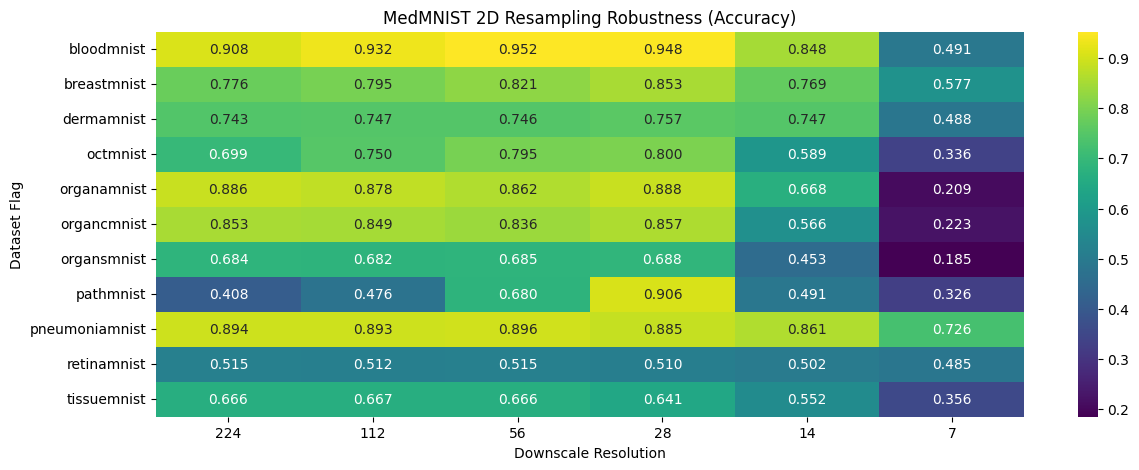

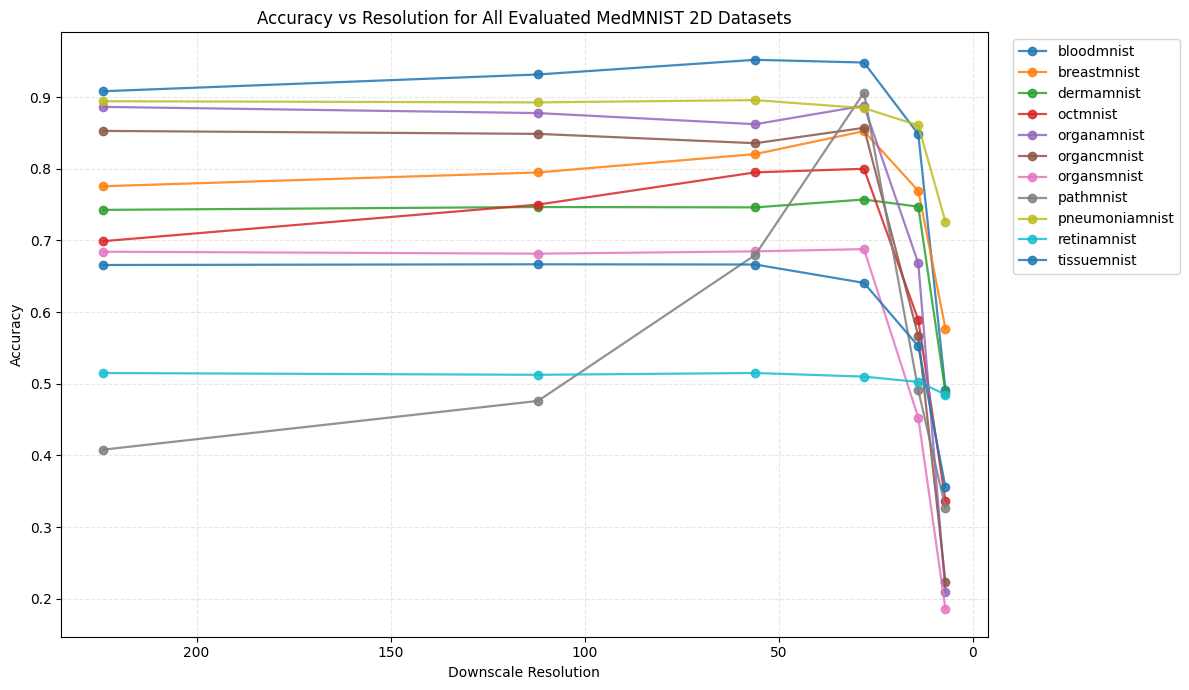

In [ ]:
if 'metrics_df' not in globals() or len(metrics_df) == 0:
    print('No metrics loaded.')
else:
    pert = metrics_df[metrics_df['interpolation'] != 'clean'].copy()
    dataset_order = sorted(pert['dataset'].unique().tolist())
    scale_order = PERTURB_CONFIG['scale_factors']
    interp_order = PERTURB_CONFIG['interpolation_methods']

    # 1) Five interpolation-specific heatmaps
    for interp in interp_order:
        sub = pert[pert['interpolation'] == interp]
        hm = sub.pivot_table(index='dataset', columns='scale_factor', values='accuracy_drop', aggfunc='mean')
        hm = hm.reindex(index=dataset_order, columns=scale_order)

        plt.figure(figsize=(8, max(5, 0.4 * len(dataset_order))))
        sns.heatmap(hm, annot=True, fmt='.3f', cmap='magma', cbar_kws={'label': 'Accuracy Drop'})
        plt.title(f'Accuracy Drop Heatmap | Interpolation={interp}')
        plt.xlabel('Scale Factor (224 -> 224/scale -> 224)')
        plt.ylabel('Dataset')
        plt.tight_layout()
        plt.show()

    # 2) Summary heatmap averaged over interpolation methods
    avg_hm = pert.groupby(['dataset', 'scale_factor'], as_index=False)['accuracy_drop'].mean()
    avg_hm = avg_hm.pivot_table(index='dataset', columns='scale_factor', values='accuracy_drop', aggfunc='mean')
    avg_hm = avg_hm.reindex(index=dataset_order, columns=scale_order)

    plt.figure(figsize=(8, max(5, 0.4 * len(dataset_order))))
    sns.heatmap(avg_hm, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Mean Accuracy Drop'})
    plt.title('Summary Heatmap: Mean Accuracy Drop Across Interpolation Methods')
    plt.xlabel('Scale Factor')
    plt.ylabel('Dataset')
    plt.tight_layout()
    plt.show()

    # 3) Grouped bar chart at scale factor 4
    scale_focus = 4
    bar_df = pert[pert['scale_factor'] == scale_focus].copy()
    bar_df['dataset'] = pd.Categorical(bar_df['dataset'], categories=dataset_order, ordered=True)
    bar_df = bar_df.sort_values('dataset')

    plt.figure(figsize=(14, 6))
    sns.barplot(data=bar_df, x='dataset', y='accuracy_drop', hue='interpolation', hue_order=interp_order)
    plt.title(f'Interpolation Comparison at {scale_focus}x Downscale (Accuracy Drop)')
    plt.xlabel('Dataset')
    plt.ylabel('Accuracy Drop')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Interpolation', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 4) SSIM vs accuracy-drop scatter
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=pert,
        x='ssim',
        y='accuracy_drop',
        hue='dataset',
        style='interpolation',
        alpha=0.85
    )
    plt.title('SSIM vs Accuracy Drop (One Point per Dataset x Scale x Interpolation)')
    plt.xlabel('Mean SSIM (Grayscale)')
    plt.ylabel('Accuracy Drop')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Output Artifacts and Rerun Behavior

Saved files:
- `./medmnist_cache/results/resampling_perturbation_metrics.csv`
- `./medmnist_cache/results/resampling_perturbation_metrics.json`
- `./medmnist_cache/results/resampling_perturbation_status.csv`

Expected aggregate rows when all 12 2D datasets succeed:
- 12 clean baseline rows
- 12 x 20 perturbation rows
- total = 252

Set `FORCE_RERUN = False` to load cached metrics without recomputing.